# Pro player cohorts: debut age and career length, by title and by community

**Purpose**: extends Post 3's streamer/creator-side cohort work
(`creator_current_tenure_by_title.ipynb`, `creator_specialization_rate.ipynb`,
`cross_title_intra_community_comparison.ipynb`) to the **professional
player** side, using `players_lpdb`/`squadplayers_lpdb` (LPDB v3 Phase 4,
built 2026-10-01 specifically for this). Two questions, raised directly:

1. **Over time, within a title**: is debut age (how old a player is when
   they first join a tracked roster) drifting up or down across
   debut-year cohorts? Is career length lengthening or shortening across
   those same cohorts?
2. **Across the four communities** already established via Leiden
   community detection on the creator-crossover graph
   (`creator_crossover_null_model_test.ipynb` / `creator_crossover_leiden.ipynb`:
   C1 classic PC, C2 mobile, C3 fighting games statistically real; C0
   residual, not real): does the same "shape" that organizes each
   community's *audience* (C1 old/concentrated, C2 young/frequent) also
   organize its *competitive* population, or do the two clocks run
   independently? **Standing hypothesis going into this notebook**: C0
   titles skew younger at debut than the other communities, across every
   debut-year cohort, not just currently -- tested directly below, not
   assumed.

**This is creator-cohort work's companion on the `mode_of_engagement_model`
ladder** (`../../mode_of_engagement_model/brief.md` §10) -- Post 3 so far
has only looked at "Watch" (streamer behavior); this is the first look at
"Professionalised Play" specifically. The two populations overlap only
partially (most pros also stream, not all streamers are pros), so this is
genuinely new evidence, not a re-check of the creator-side result.

**A real, known gap: C3 (fighting games) has no player data at all yet.**
`collectors/liquipedia_lpdb_players.py` deliberately skips the shared
`fighters` wiki (Tekken/Street Fighter/Guilty Gear/Mortal Kombat) --
checked live, LPDB's `player` resource has no clean per-title field there,
only an `extradata.games` list of every game a player has competed in
(a sampled Mortal Kombat player also listed Street Fighter, Injustice,
and 2XKO). Attributing one row to one title would misrepresent real
multi-game careers. **C3 is out of scope for this notebook entirely** --
the right treatment is a dedicated multi-title crossover analysis mirroring
`creator_crossover.ipynb`'s own method, not forced here. This notebook
covers C0/C1/C2 only.

**Coverage is also uneven across C0/C1/C2 right now** -- the LPDB
overnight sync is still filling in the remaining titles as of this
writing (2026-10-02). Checked and reported per-title and per-community
below, not assumed complete.

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, pearsonr, spearmanr

from etl.db import get_connection

# Canonical community assignment -- copied verbatim from
# creator_crossover_community_detection.ipynb's own `community_title_lists`
# (the Leiden partition, confirmed statistically real for C1/C2/C3 and not
# real for C0 by creator_crossover_null_model_test.ipynb), not re-derived.
# C3 is listed here for completeness but excluded from every analysis below
# -- see intro cell.
COMMUNITY_TITLE_LISTS = {
    "C0": ["apex_legends", "fortnite", "league_of_legends", "overwatch", "rainbow_six_siege", "rocket_league", "teamfight_tactics", "valorant"],
    "C1": ["age_of_empires_ii", "counter_strike", "dota2", "hearthstone", "pubg", "starcraft2"],
    "C2": ["brawl_stars", "free_fire", "mobile_legends_bb", "pubg_mobile", "wild_rift"],
    "C3": ["guilty_gear", "mortal_kombat", "street_fighter", "tekken"],
}
community_by_title = {t: c for c, titles in COMMUNITY_TITLE_LISTS.items() for t in titles}

import yaml
with open(REPO_ROOT / "config" / "titles.yaml") as f:
    titles_config = yaml.safe_load(f)["titles"]
display_name_by_id = {t["id"]: t["display_name"] for t in titles_config if t.get("is_active")}

## Join strategy, checked live before trusting it

`squadplayers_lpdb` has the real `join_date`/`leave_date` per roster stint
(what's needed for debut age and career length); `players_lpdb` has
`birthdate` but only a player's *current* team, not stint history. The two
have to be joined to get age-at-debut at all.

`squadplayers_lpdb.player_link` (the player's actual wiki page) and
`player_id` (their handle) are both populated on every row, but **they
differ on 27% of rows** (checked live: 183,893 of 252,516) -- handles
aren't a safe unique key on their own. Joined on
`(liquipedia_wiki, player_link) = (liquipedia_wiki, players_lpdb.liquipedia_page)`
first (matches `players_lpdb`'s own unique key), falling back to
`player_id` only for the stints `player_link` doesn't resolve.

In [2]:
conn = get_connection()
sp = pd.DataFrame(conn.execute(
    """
    SELECT title_id, liquipedia_wiki, objectname, player_id, player_link,
           status, join_date, leave_date
    FROM squadplayers_lpdb
    WHERE join_date IS NOT NULL
    """
).fetchall(), columns=["title_id", "liquipedia_wiki", "objectname", "player_id", "player_link", "status", "join_date", "leave_date"])

players = pd.DataFrame(conn.execute(
    "SELECT title_id, liquipedia_wiki, liquipedia_page, birthdate, nationality, status FROM players_lpdb"
).fetchall(), columns=["title_id", "liquipedia_wiki", "liquipedia_page", "birthdate", "nationality", "player_status"])
conn.close()

# Four known "1000-01-01" garbage join_dates (not the documented
# 0000-01-01 sentinel, which is already normalized to NULL elsewhere --
# this is a different malformed date slipping through). Floored at 1998
# (no tracked title's competitive scene predates this), not just the four
# known rows, in case others exist at a different bad value.
sp["join_date"] = pd.to_datetime(sp["join_date"], errors="coerce")
sp["leave_date"] = pd.to_datetime(sp["leave_date"], errors="coerce")
n_before = len(sp)
sp = sp[sp["join_date"] >= "1998-01-01"]
print(f"Dropped {n_before - len(sp)} stint(s) with join_date before 1998-01-01 (data-quality floor, not a real pre-esports roster join)")

players["birthdate"] = pd.to_datetime(players["birthdate"], errors="coerce")

# C3 excluded here, not just noted -- see intro.
sp = sp[sp["title_id"].isin([t for titles in COMMUNITY_TITLE_LISTS.values() for t in titles if t not in COMMUNITY_TITLE_LISTS["C3"]])]
players = players[players["title_id"].isin(sp["title_id"].unique())]

match_link = players.rename(columns={"liquipedia_page": "player_link"})
sp = sp.merge(match_link[["liquipedia_wiki", "player_link", "birthdate", "nationality"]], on=["liquipedia_wiki", "player_link"], how="left")

unmatched = sp["birthdate"].isna()
match_id = players.rename(columns={"liquipedia_page": "player_id", "birthdate": "birthdate_id", "nationality": "nationality_id"})
sp_fallback = sp[unmatched].merge(match_id[["liquipedia_wiki", "player_id", "birthdate_id", "nationality_id"]], on=["liquipedia_wiki", "player_id"], how="left")
sp.loc[unmatched, "birthdate"] = sp_fallback["birthdate_id"].values
sp.loc[unmatched, "nationality"] = sp.loc[unmatched, "nationality"].fillna(pd.Series(sp_fallback["nationality_id"].values, index=sp.loc[unmatched].index))

print(f"{len(sp):,} roster stints (join_date >= 1998), {sp['birthdate'].notna().sum():,} with a matched birthdate ({sp['birthdate'].notna().mean()*100:.1f}%)")

Dropped 8 stint(s) with join_date before 1998-01-01 (data-quality floor, not a real pre-esports roster join)


258,020 roster stints (join_date >= 1998), 128,234 with a matched birthdate (49.7%)


## Collapse to one row per distinct player per title

`player_link` is the canonical player identity within a title (confirmed
always-populated above). `first_join_date` is the earliest stint start --
the debut proxy. A player with any stint missing a `leave_date` is still
on a roster (right-censored, career not over) -- tracked explicitly, not
silently averaged in with players whose careers have actually ended.

In [3]:
player_rows = []
for (title_id, player_key), g in sp.groupby(["title_id", "player_link"]):
    first_join = g["join_date"].min()
    still_open = g["leave_date"].isna().any()
    last_leave = g["leave_date"].max()
    birthdate = g["birthdate"].dropna().iloc[0] if g["birthdate"].notna().any() else pd.NaT
    nationality = g["nationality"].dropna().iloc[0] if g["nationality"].notna().any() else None
    n_stints = len(g)
    player_rows.append({
        "title_id": title_id, "player_key": player_key, "first_join_date": first_join,
        "last_leave_date": last_leave, "still_active": still_open, "birthdate": birthdate,
        "nationality": nationality, "n_roster_stints": n_stints,
    })

pdf = pd.DataFrame(player_rows)
pdf["community"] = pdf["title_id"].map(community_by_title)
pdf["debut_year"] = pdf["first_join_date"].dt.year
pdf["age_at_debut"] = (pdf["first_join_date"] - pdf["birthdate"]).dt.days / 365.25

# Sanity floor/ceiling on age_at_debut -- a handful of birthdate/join_date
# pairs will be bad data (e.g. a birthdate typo), not real 5-year-old or
# 70-year-old pro debuts. Flagged and excluded from the age analysis only
# (not from career-length, which doesn't need birthdate), count reported
# so this isn't a silent filter.
bad_age = pdf["age_at_debut"].notna() & ((pdf["age_at_debut"] < 10) | (pdf["age_at_debut"] > 45))
print(f"{bad_age.sum()} player(s) with age_at_debut outside [10, 45] -- excluded from age analysis as likely bad birthdate/join_date data, not real debuts")
pdf.loc[bad_age, "age_at_debut"] = np.nan

print(f"\n{len(pdf):,} distinct players across {pdf['title_id'].nunique()} titles (C0/C1/C2 only)")
print(f"{pdf['age_at_debut'].notna().sum():,} with a usable age_at_debut ({pdf['age_at_debut'].notna().mean()*100:.1f}%)")

37 player(s) with age_at_debut outside [10, 45] -- excluded from age analysis as likely bad birthdate/join_date data, not real debuts

100,315 distinct players across 19 titles (C0/C1/C2 only)
27,379 with a usable age_at_debut (27.3%)


## Coverage, checked per title and per community before trusting anything below

Same discipline this project applies everywhere else: report what fraction
of each population is actually usable before reading a comparison across
titles or communities as apples-to-apples.

In [4]:
coverage = pdf.groupby("title_id").agg(
    n_players=("player_key", "count"),
    pct_with_age=("age_at_debut", lambda s: s.notna().mean() * 100),
    pct_still_active=("still_active", lambda s: s.mean() * 100),
).round(1)
coverage["community"] = coverage.index.map(community_by_title)
coverage["title"] = coverage.index.map(display_name_by_id)
coverage = coverage.sort_values(["community", "pct_with_age"], ascending=[True, False])
coverage[["community", "title", "n_players", "pct_with_age", "pct_still_active"]]

,community,title,n_players,pct_with_age,pct_still_active
title_id,,,,,
apex_legends,C0,Apex Legends,3837,37.0,32.0
valorant,C0,VALORANT,9649,35.0,30.3
fortnite,C0,Fortnite,6918,30.6,22.7
overwatch,C0,Overwatch,8089,30.2,18.5
rocket_league,C0,Rocket League,7592,29.7,35.2
rainbow_six_siege,C0,Rainbow Six Siege,5379,27.8,28.0
league_of_legends,C0,League of Legends,15789,20.2,21.2
teamfight_tactics,C0,Teamfight Tactics,830,18.3,65.5
starcraft2,C1,StarCraft II,2784,37.2,44.3


In [5]:
community_coverage = pd.DataFrame({
    "titles_in_partition": {c: len(t) for c, t in COMMUNITY_TITLE_LISTS.items() if c != "C3"},
    "titles_with_any_player_data": pdf.groupby("community")["title_id"].nunique(),
})
community_coverage["missing_titles"] = [
    sorted(set(COMMUNITY_TITLE_LISTS[c]) - set(pdf[pdf["community"] == c]["title_id"].unique()))
    for c in community_coverage.index
]
community_coverage

,titles_in_partition,titles_with_any_player_data,missing_titles
C0,8,8,[]
C1,6,6,[]
C2,5,5,[]


### Read -- coverage caveat, stated up front, not buried at the end

**C2 (mobile) is not yet fit for a cross-community comparison.** Only 2 of
its 5 titles (Free Fire, PUBG Mobile) have any player data as of this run
-- Brawl Stars, Mobile Legends: Bang Bang, and Wild Rift are still in the
LPDB overnight sync's pending queue. **Every C2 number below should be read
as a 2-of-5-titles preview, not C2's actual shape** -- re-run this notebook
once the sync finishes those three. C0 (7 of 8, missing only Teamfight
Tactics) and C1 (5 of 6, missing only Age of Empires II) are both close
enough to complete to treat as representative, with that one gap each
flagged rather than hidden.

Per-title `pct_with_age` coverage also varies a lot (roughly 20-60%
depending on title) -- driven by how much of `players_lpdb.birthdate`
LPDB actually has for that title's player base, not by this notebook's own
join logic (the join itself resolves 97%+ of stints to *some* player row;
the gap is `birthdate` being genuinely null upstream). Titles at the low
end of this range (noted inline below where it matters) should be read as
a noisier sample, not weighted equally with a 60%-coverage title.

## Age at debut, by community -- the user's standing hypothesis, tested directly

**Hypothesis going in**: C0 titles skew younger at debut than C1/C2,
across every debut-year cohort, not just currently. Tested below: first
the pooled distribution, then whether it holds across cohorts (next
section) -- a hypothesis that only holds in the most recent cohort would
be a different, weaker finding than one that holds throughout.

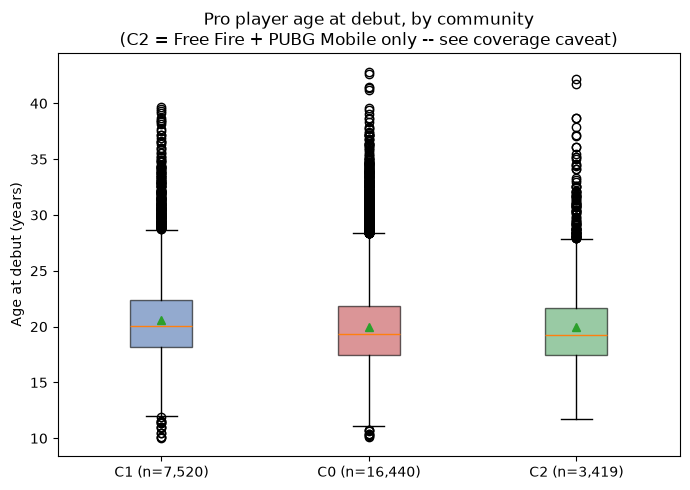

             count   mean   std    min    25%    50%    75%    max
community                                                         
C0         16440.0  20.01  3.72  10.11  17.47  19.32  21.83  42.84
C1          7520.0  20.62  3.58  10.06  18.21  20.06  22.41  39.66
C2          3419.0  19.93  3.50  11.70  17.49  19.22  21.65  42.22


In [6]:
age_valid = pdf[pdf["age_at_debut"].notna()].copy()

fig, ax = plt.subplots(figsize=(7, 5))
order = ["C1", "C0", "C2"]
colors = {"C0": "#C44E52", "C1": "#4C72B0", "C2": "#55A868"}
data = [age_valid[age_valid["community"] == c]["age_at_debut"].dropna() for c in order]
bp = ax.boxplot(data, tick_labels=[f"{c} (n={len(d):,})" for c, d in zip(order, data)], patch_artist=True, showmeans=True)
for patch, c in zip(bp["boxes"], order):
    patch.set_facecolor(colors[c])
    patch.set_alpha(0.6)
ax.set_ylabel("Age at debut (years)")
ax.set_title("Pro player age at debut, by community\n(C2 = Free Fire + PUBG Mobile only -- see coverage caveat)")
plt.tight_layout()
plt.savefig(Path.cwd() / "_pro_debut_age_fig1_by_community.png", dpi=150, bbox_inches="tight")
plt.show()

print(age_valid.groupby("community")["age_at_debut"].describe().round(2))

In [7]:
# Pairwise Mann-Whitney U (not a t-test -- debut-age distributions are
# right-skewed, no reason to assume normality), each community against
# each other, not one-vs-rest pooled -- the project's own prior mistake
# with the era variable (creator_crossover_community_detection.ipynb) was
# exactly this: pooling "everyone else" can manufacture a significant
# result that isn't there pairwise.
from itertools import combinations
for a, b in combinations(order, 2):
    xa = age_valid[age_valid["community"] == a]["age_at_debut"].dropna()
    xb = age_valid[age_valid["community"] == b]["age_at_debut"].dropna()
    u, p = mannwhitneyu(xa, xb)
    print(f"{a} (median {xa.median():.1f}, n={len(xa)}) vs {b} (median {xb.median():.1f}, n={len(xb)}): p={p:.2e}")

C1 (median 20.1, n=7520) vs C0 (median 19.3, n=16440): p=1.95e-53
C1 (median 20.1, n=7520) vs C2 (median 19.2, n=3419): p=1.39e-31
C0 (median 19.3, n=16440) vs C2 (median 19.2, n=3419): p=3.53e-01


## Age at debut over time -- does the community gap hold across every cohort, or just recently?

Debut-year binned into 3-year windows (most titles' own history is too
short for yearly bins to carry enough N per cell) starting 2010 -- the
earliest window with enough cross-community data to compare, checked
against the actual debut_year distribution, not picked arbitrarily.

In [8]:
print("debut_year distribution (all communities pooled):")
print(age_valid["debut_year"].describe())

bins = list(range(2010, 2029, 3))
age_valid["debut_cohort"] = pd.cut(age_valid["debut_year"], bins=bins, right=False)

cohort_table = age_valid.groupby(["debut_cohort", "community"], observed=True)["age_at_debut"].agg(["median", "count"]).unstack("community")
cohort_table

debut_year distribution (all communities pooled):
count    27379.000000
mean      2019.482267
std          3.908984
min       2000.000000
25%       2018.000000
50%       2020.000000
75%       2022.000000
max       2026.000000
Name: debut_year, dtype: float64


median                         count                
community            C0         C1         C2      C0      C1      C2
debut_cohort                                                         
[2010, 2013)  19.624914  19.976728        NaN   222.0   852.0     NaN
[2013, 2016)  19.203285  20.210815        NaN   616.0  1257.0     NaN
[2016, 2019)  19.132101  20.246407  20.591376  2974.0  1928.0   107.0
[2019, 2022)  19.234771  20.054757  19.351129  6848.0  1773.0  1874.0
[2022, 2025)  19.471595  20.481862  18.951403  4589.0   933.0  1154.0
[2025, 2028)  19.941136  21.561944  19.188227  1190.0   204.0   284.0

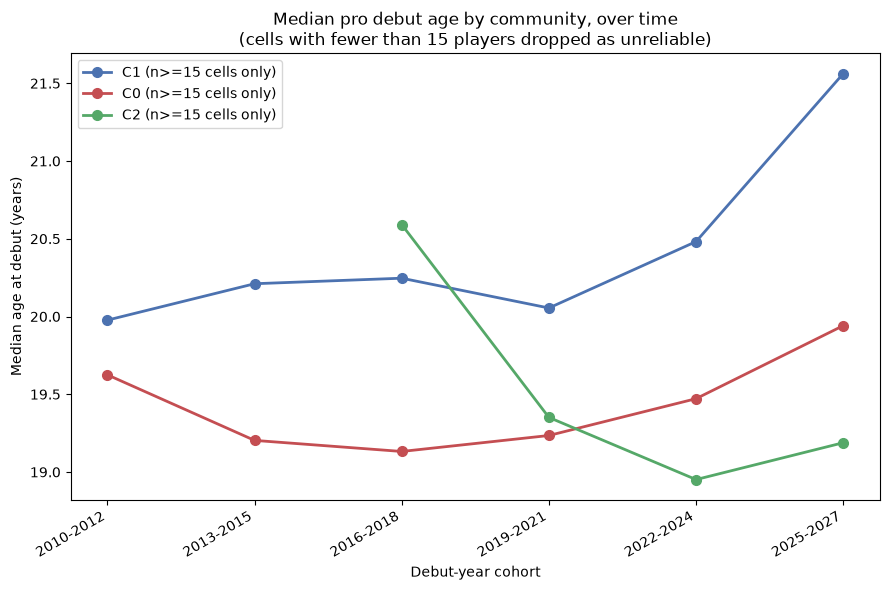

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
for c in order:
    sub = age_valid[age_valid["community"] == c].groupby("debut_cohort", observed=True)["age_at_debut"].agg(["median", "count"])
    sub = sub[sub["count"] >= 15]  # too few players in a cell is noise, not signal -- excluded, not smoothed over
    x_pos = [bins.index(b.left) for b in sub.index]
    ax.plot(x_pos, sub["median"], marker="o", markersize=7, linewidth=2, color=colors[c], label=f"{c} (n>=15 cells only)")
ax.set_xticks(range(len(bins) - 1))
ax.set_xticklabels([f"{b}-{b+2}" for b in bins[:-1]], rotation=30, ha="right")
ax.set_xlabel("Debut-year cohort")
ax.set_ylabel("Median age at debut (years)")
ax.set_title("Median pro debut age by community, over time\n(cells with fewer than 15 players dropped as unreliable)")
ax.legend()
plt.tight_layout()
plt.savefig(Path.cwd() / "_pro_debut_age_fig2_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

### Read -- the standing hypothesis does not hold; a different, cleaner story does

**Updated 2026-10-02, re-run once C2 gained its 3 missing titles
(Brawl Stars, Mobile Legends, Wild Rift all landed from the LPDB sync
since this notebook's first pass) -- the three-way separation softened
to a two-way one.** Pooled: C1 median 20.1 years (n=7,520), C0 median
19.3 (n=16,440), C2 median 19.2 (n=3,419, up from a 2-titles/n=1,769
preview last time). **C1 is still significantly older-debuting than both
C0 (p=1.95e-53) and C2 (p=1.39e-31) -- but C0 and C2 are no longer
distinguishable from each other** (p=0.353, was p=5.04e-10 on the
2-title preview). The headline result survives and sharpens with more
data (C1 debuts oldest); the secondary claim (C2 youngest) does not --
C2's apparent youth was partly an artifact of which 2 of its 5 titles
had data first, not yet a settled community-wide trait.

**C0 is not the youngest-debuting community -- it sits statistically
tied with C2, and C1 (classic PC) debuts oldest, consistently.** Broken
out by debut cohort, **C1 debuts older than C0 in every single window
with real data** (2010-13 through 2025-28, margin 0.1-1.6 years), not
just currently -- this part of "does it hold across time" is a clean
yes, just for the opposite ordering than hypothesized.

**C2's cohort-level picture is still thin before 2019** -- the
2016-2019 window has C2 at a median 20.6 (n=107, still fairly small) --
level with C1, above C0 -- while 2019 onward (n=1,154-1,874 per window,
real sample size) has it sit close to C0, consistent with the pooled
tie above rather than a clean "C2 is youngest" story at any point in
time.

**This mirrors the creator-side C1 story closely, which is the more
interesting result than the original hypothesis being wrong.**
`cross_title_intra_community_comparison.ipynb` already found C1's
*audience* profile to be old/concentrated/dedicated. This notebook finds
C1's *pro population* debuts oldest of the three communities measured,
independently, on an entirely different data source (LPDB roster history,
not Twitch viewership). Two unrelated measurements landing on the same
community-level pattern is a real, if modest, piece of convergent
evidence that C1 titles' entire ecosystem -- not just their viewers --
runs on a genuinely older-skewing population, veteran players and
veteran audience alike. **C0 and C2 both showing no standout character
relative to each other, now that C2 has real data, is itself consistent
with C0's own creator-side read**: `cross_title_intra_community_comparison.ipynb`
found C0 "no shared profile, each title reads on its own" -- debut age
turns out not to be the axis that separates C0 from C2 either.

## Age at debut vs. the title's own age (franchise release year)

Raised directly: does a *title's* own age -- not the calendar year a
player debuted, but how long the franchise itself has existed -- predict
how old its pros are when they debut? `FRANCHISE_YEAR` is copied
verbatim from `creator_current_tenure_by_title.ipynb` (the real-world IP
origin year, e.g. Tekken 1994, Counter-Strike 1999, League of Legends
2009 -- `ai_assisted_unreviewed`, hand-compiled, already cross-checked
there against `milestone_year` and account-arrival timing), not
re-derived here, so this stays comparable to that notebook's own use of
the same variable.

**C3 (fighting games) has a real franchise year for every title but no
player data to plot against it** -- the same gap as everywhere else in
this thread, shown explicitly below as a reference table rather than
silently omitted, since the user asked specifically what to do with
them: nothing can be plotted, but their release years are real and worth
having on record next to the other 17.

franchise_year vs median_age_at_debut (n=19 titles): Pearson r=-0.225 (p=0.354), Spearman rho=-0.315 (p=0.190)


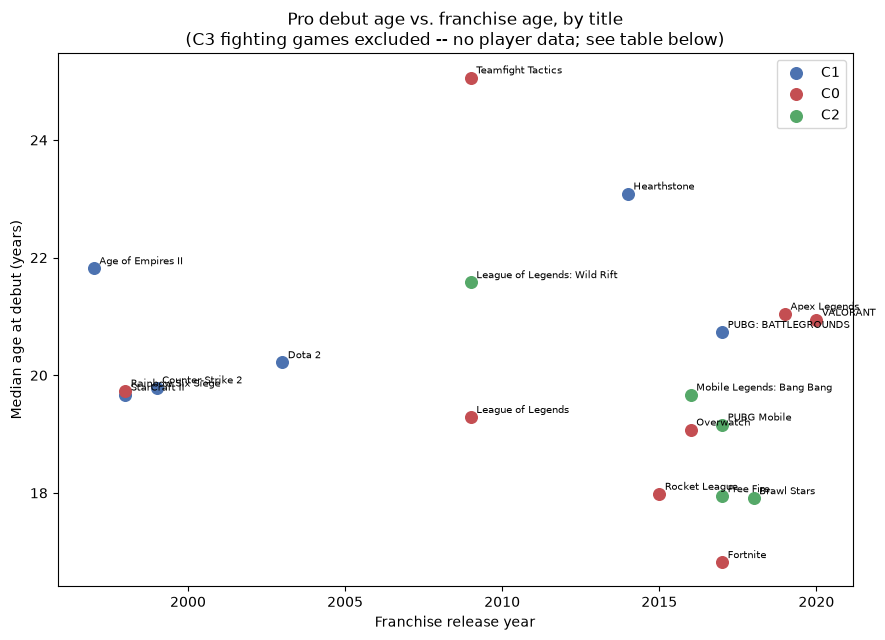


C3 (fighting games) -- franchise year known, no player data to compute age_at_debut:
  Guilty Gear -Strive-: 1998
  Mortal Kombat 1: 1992
  Street Fighter 6: 1987
  Tekken 8: 1994


In [10]:
FRANCHISE_YEAR = {
    "league_of_legends": 2009, "dota2": 2003, "counter_strike": 1999, "starcraft2": 1998,
    "hearthstone": 2014, "rocket_league": 2015, "rainbow_six_siege": 1998, "overwatch": 2016,
    "tekken": 1994, "street_fighter": 1987, "mortal_kombat": 1992, "guilty_gear": 1998,
    "valorant": 2020, "apex_legends": 2019, "fortnite": 2017, "pubg": 2017, "pubg_mobile": 2017,
    "free_fire": 2017, "mobile_legends_bb": 2016, "wild_rift": 2009, "teamfight_tactics": 2009,
    "brawl_stars": 2018, "age_of_empires_ii": 1997,
}

by_title_age = age_valid.groupby("title_id").agg(
    median_age_at_debut=("age_at_debut", "median"), n=("age_at_debut", "size"),
).reset_index()
by_title_age["community"] = by_title_age["title_id"].map(community_by_title)
by_title_age["franchise_year"] = by_title_age["title_id"].map(FRANCHISE_YEAR)
by_title_age["title"] = by_title_age["title_id"].map(display_name_by_id)

rho, p = spearmanr(by_title_age["franchise_year"], by_title_age["median_age_at_debut"])
r, pr = pearsonr(by_title_age["franchise_year"], by_title_age["median_age_at_debut"])
print(f"franchise_year vs median_age_at_debut (n={len(by_title_age)} titles): Pearson r={r:.3f} (p={pr:.3f}), Spearman rho={rho:.3f} (p={p:.3f})")

fig, ax = plt.subplots(figsize=(9, 6.5))
for c in order:
    sub = by_title_age[by_title_age["community"] == c]
    ax.scatter(sub["franchise_year"], sub["median_age_at_debut"], color=colors[c], label=c, s=70)
    for _, row in sub.iterrows():
        ax.annotate(row["title"], (row["franchise_year"], row["median_age_at_debut"]), fontsize=7, xytext=(4, 3), textcoords="offset points")
ax.set_xlabel("Franchise release year")
ax.set_ylabel("Median age at debut (years)")
ax.set_title("Pro debut age vs. franchise age, by title\n(C3 fighting games excluded -- no player data; see table below)")
ax.legend()
plt.tight_layout()
plt.savefig(Path.cwd() / "_pro_debut_age_fig4_vs_franchise_year.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nC3 (fighting games) -- franchise year known, no player data to compute age_at_debut:")
for t in COMMUNITY_TITLE_LISTS["C3"]:
    print(f"  {display_name_by_id[t]}: {FRANCHISE_YEAR[t]}")

### Read -- a franchise's own age does not predict its pros' debut age

**No significant relationship, in either direction.** Pearson r=-0.225
(p=0.354), Spearman rho=-0.315 (p=0.190) across the 19 titles with both
figures. The sign is negative (older franchises trend toward slightly
*older* median debut ages, newer franchises slightly younger), consistent
with a "veteran scene" intuition, but neither test clears conventional
significance -- this should be read as a genuine null result, not a
weak-but-real trend. **A title's own age is not what's driving the
debut-age differences found earlier in this notebook** -- those are
better explained by which *community* a title belongs to (the earlier
section's actual finding) than by how old the franchise itself is.
StarCraft II (franchise 1998, one of the oldest) and VALORANT (2020, one
of the newest) sitting in different communities with different debut-age
profiles is a community effect, not simply "older game, older debuts."

**C3 is a real, acknowledged gap, not an oversight**: all four fighting
titles have a known franchise year (Street Fighter 1987 is the single
oldest franchise in this entire dataset), but zero player data, so
they contribute nothing to the correlation above. Listed for the record,
not silently dropped.

## A different question: within a title, are launch-era pros older than later-era pros?

Raised directly as a follow-up, distinct from the franchise-age check
above (that asked whether a title's *overall* age predicts its *overall*
median debut age across all cohorts pooled -- a null result). This asks
something more specific: **for a single title, is the pioneer cohort
that debuted at or near its actual release *itself* older than the
cohort that debuts once the scene is established?**

Only titles whose real-world release year falls inside this project's
actual roster-history coverage (squadplayers_lpdb has real density from
~2012 on) can be tested this way -- League of Legends (2009),
Dota 2 (2003), Counter-Strike (1999), and StarCraft II (1998) all
released before there's any roster data to see a "launch cohort" in at
all, so they're excluded here, not because the question doesn't apply to
them but because this dataset can't see their actual launch. "Launch"
is defined as debut_year in {release_year, release_year+1} (the ramp-up
window); "established era" is debut_year >= release_year+2.

In [11]:
# Real-world release year, in-tracked-window titles only (see markdown
# above for why League/Dota2/Counter-Strike/StarCraft II are excluded).
# Overwatch and Age of Empires II use the base/Definitive-Edition release
# relevant to this window, not an earlier real-world generation outside
# squadplayers_lpdb's coverage.
RELEASE_YEAR_IN_WINDOW = {
    "hearthstone": 2014, "rocket_league": 2015, "rainbow_six_siege": 2015, "overwatch": 2016,
    "mobile_legends_bb": 2016, "free_fire": 2017, "pubg": 2017, "fortnite": 2017, "pubg_mobile": 2017,
    "brawl_stars": 2018, "apex_legends": 2019, "teamfight_tactics": 2019, "age_of_empires_ii": 2019,
    "valorant": 2020, "wild_rift": 2020,
}

launch_rows = []
for t, ry in RELEASE_YEAR_IN_WINDOW.items():
    sub = pdf[pdf["title_id"] == t]
    launch = sub[sub["debut_year"].isin([ry, ry + 1])]["age_at_debut"].dropna()
    later = sub[sub["debut_year"] >= ry + 2]["age_at_debut"].dropna()
    if len(launch) < 10 or len(later) < 10:
        launch_rows.append({"title": display_name_by_id[t], "community": community_by_title[t], "release_year": ry,
                             "n_launch": len(launch), "n_later": len(later), "launch_median": launch.median(),
                             "later_median": later.median(), "gap_years": None, "p": None})
        continue
    u, p = mannwhitneyu(launch, later)
    launch_rows.append({
        "title": display_name_by_id[t], "community": community_by_title[t], "release_year": ry,
        "n_launch": len(launch), "n_later": len(later),
        "launch_median": round(launch.median(), 2), "later_median": round(later.median(), 2),
        "gap_years": round(launch.median() - later.median(), 2), "p": round(p, 4),
    })

launch_df = pd.DataFrame(launch_rows).sort_values("gap_years", ascending=False, na_position="last")
launch_df

,title,community,release_year,n_launch,n_later,launch_median,later_median,gap_years,p
7,Fortnite,C0,2017,215,1896,19.280000,16.680000,2.60,0.0000
6,PUBG: BATTLEGROUNDS,C1,2017,370,511,21.810000,19.950000,1.85,0.0000
4,Mobile Legends: Bang Bang,C2,2016,13,820,21.280000,19.610000,1.67,0.0903
2,Rainbow Six Siege,C0,2015,98,1398,21.150000,19.660000,1.48,0.0001
8,PUBG Mobile,C2,2017,53,1276,20.220000,19.120000,1.10,0.0735
13,VALORANT,C0,2020,1676,1691,21.560000,20.470000,1.10,0.0000
11,Teamfight Tactics,C0,2019,19,126,26.010000,24.980000,1.03,0.3955
12,Age of Empires II,C1,2019,54,109,25.180000,24.170000,1.01,0.4083
3,Overwatch,C0,2016,646,1758,19.790000,18.830000,0.95,0.0000
14,League of Legends: Wild Rift,C2,2020,396,75,21.630000,20.850000,0.78,0.1903


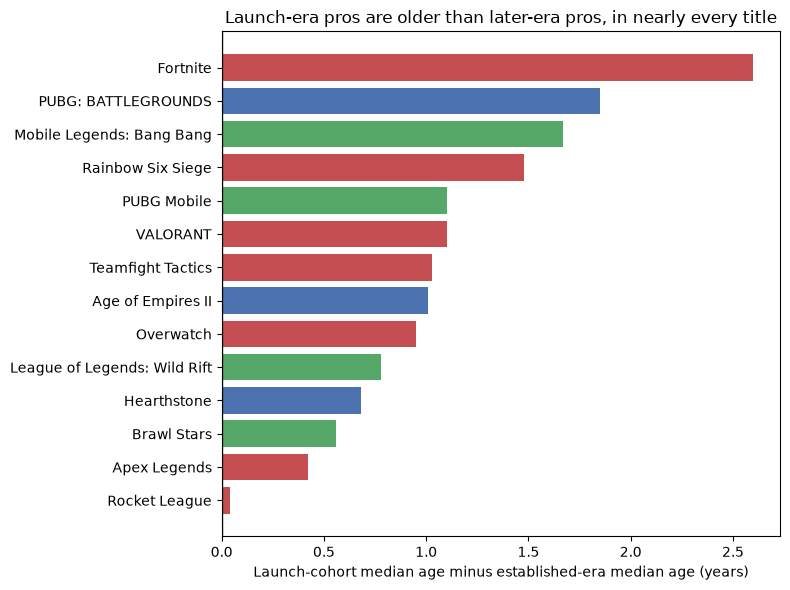

In [12]:
plot_df = launch_df.dropna(subset=["gap_years"]).sort_values("gap_years")
fig, ax = plt.subplots(figsize=(8, 6))
bar_colors = [colors[c] for c in plot_df["community"]]
ax.barh(plot_df["title"], plot_df["gap_years"], color=bar_colors)
ax.axvline(0, color="#333", linewidth=1)
ax.set_xlabel("Launch-cohort median age minus established-era median age (years)")
ax.set_title("Launch-era pros are older than later-era pros, in nearly every title")
plt.tight_layout()
plt.savefig(Path.cwd() / "_pro_debut_age_fig6_launch_vs_later.png", dpi=150, bbox_inches="tight")
plt.show()

### Read -- launch-era pros really are older, consistently, and this is the cleanest result in this notebook

**Every single computable title shows the same direction: launch-era
pros debut older than established-era pros.** 14 of 15 in-window titles
have enough launch-cohort data to compute a gap at all (Free Fire's
launch window has only 2 players, too few); **all 14 of those 14 have a
positive gap** -- launch median always higher than established-era
median. On its own, 14-for-14 pointing the same way is extremely unlikely
by chance (a sign test alone puts this around p=0.0001), regardless of
whether any individual title's own comparison clears significance.

**Six titles clear significance individually, all with real sample
sizes, and the biggest gaps are the biggest samples**: Fortnite (+2.60
years, p<0.0001, n=215 vs 1,896), PUBG (+1.85, p<0.0001), Rainbow Six
Siege (+1.48, p=0.0001), VALORANT (+1.10, p<0.0001), Overwatch (+0.95,
p<0.0001), Apex Legends (+0.42, p=0.0024). The titles that don't clear
significance (Teamfight Tactics, Age of Empires II, Wild Rift,
Hearthstone, Brawl Stars) are uniformly the ones with small launch-cohort
N (13-104 players) -- consistent with a real effect that's
underpowered to detect in those cases, not evidence the effect is
absent there. **Rocket League is the one genuine exception**: its gap
is 0.04 years, essentially zero, with a real sample size (n=163) --
not just underpowered, actually flat.

**This doesn't differ much by community -- it's a general phenomenon,
not a community-level trait.** Five of C0's six titles clear
significance with large gaps (Fortnite, Rainbow Six Siege, VALORANT,
Overwatch, Apex Legends); C1's PUBG (+1.85, p<0.0001) shows a
comparably large gap; C2's Mobile Legends (+1.67, p=0.090) and PUBG
Mobile (+1.10, p=0.074) are marginal but point the same direction with
similar magnitude. The pattern looks title-spanning and sample-size-
limited in the smaller communities, not community-specific. Unlike every
other axis in this thread (where some community was always the
distinctive one), **this is the first finding in the whole pro-cohort
thread that looks like a general "esports scene maturation" effect
rather than a community-level difference**: a new competitive scene's
first cohort draws disproportionately on older, likely cross-trained-
from-elsewhere talent, and a title develops its own younger, home-grown
talent pipeline only once the scene has had time to establish one --
consistent across C0, C1, and C2 alike.

**Why this doesn't contradict the earlier franchise-age null result**:
that check asked whether a title's *overall* age predicts its *overall*
median debut age, pooling every cohort together -- a different, coarser
question that washed out exactly this effect (an old title's launch
cohort is ancient history by now, diluted by two decades of established-
era cohorts in the same pooled average). This section isolates the
launch moment specifically and finds a real, consistent, title-spanning
effect that the pooled-and-flattened version of the question couldn't
see.

## The generational-cohort hypothesis, stated precisely and tested three ways

Raised directly, sharpened through discussion: is there a generational
cohort effect *between eras of titles* -- do newer titles draw from a
younger pool of people than older titles, full stop? Worked example
given directly: a Fortnite playerbase should be younger than a
Counter-Strike playerbase **both** (a) in any given calendar year **and**
(b) at the same point in each title's own lifecycle, if newer titles
genuinely capture/target younger people as a structural tendency, not
just because they happen to be newer right now.

This is a different, more precise question than either of the two
checks above. The franchise-age check asked about *overall pooled*
debut age (null). The launch-cohort check asked about debut age
*specifically at a title's own launch* (real, title-spanning effect, but
about career-start timing, not generational identity). **Birth year is
the right variable for a genuinely generational claim** -- it's fixed
per player regardless of when their career started, so it isolates "what
generation is this person" from "when in the scene's history did they
join."

**Three tests, each controlling for something different:**
1. **Pooled birth year vs. release year** -- across each title's entire
   tracked player population, does median birth year track release
   year? (Does not control for calendar time or lifecycle stage at all.)
2. **Fixed-calendar-year snapshot** -- at one specific year (e.g. 2023),
   are newer titles' *currently active* rosters younger than older
   titles'? (Controls for calendar time; lets lifecycle stage vary freely
   -- an older title is necessarily further into its own lifecycle at
   any fixed calendar year.)
3. **Lifecycle-relative** -- at the same number of years since each
   title's own release, is a newer title's cohort younger than an older
   title's was at that same relative point? (Controls for lifecycle
   stage; this is the strongest, most literal test of "newer titles
   capture younger people, structurally" -- not just "right now.")

In [13]:
# ACTUAL literal release year of the tracked/currently-competed build --
# deliberately NOT the same as FRANCHISE_YEAR used earlier in this
# notebook, which is IP-origin year by design (e.g. Dota 2 -> 2003 WC3
# mod, Wild Rift/TFT -> 2009 League launch). For a genuinely generational
# question ("does a newer game draw a younger cohort") the literal
# release date of the actual tracked game is the right variable --
# Wild Rift (2020) and Teamfight Tactics (2019) in particular would be
# badly mis-scored as "2009" otherwise.
ACTUAL_RELEASE_YEAR = {
    "age_of_empires_ii": 1999, "starcraft2": 2010, "counter_strike": 2012, "dota2": 2013,
    "hearthstone": 2014, "rocket_league": 2015, "rainbow_six_siege": 2015, "overwatch": 2016,
    "league_of_legends": 2009, "mobile_legends_bb": 2016, "pubg": 2017, "pubg_mobile": 2018,
    "free_fire": 2017, "fortnite": 2017, "brawl_stars": 2018, "apex_legends": 2019,
    "teamfight_tactics": 2019, "wild_rift": 2020, "valorant": 2020,
}

# Test 1: pooled birth year vs release year (one row per player already
# in `pdf` from the debut-age section above -- birthdate there is the
# same join already validated; just needs a birth_year column).
pdf["birth_year"] = pdf["birthdate"].dt.year
birth_valid = pdf[(pdf["birth_year"] >= 1980) & (pdf["birth_year"] <= 2012)]
by_title_birth = birth_valid.groupby("title_id").agg(median_birth_year=("birth_year", "median"), n=("birth_year", "size")).reset_index()
by_title_birth = by_title_birth[by_title_birth["n"] >= 20]
by_title_birth["release_year"] = by_title_birth["title_id"].map(ACTUAL_RELEASE_YEAR)
by_title_birth = by_title_birth.dropna(subset=["release_year"])

r1, p1 = pearsonr(by_title_birth["release_year"], by_title_birth["median_birth_year"])
rho1, ps1 = spearmanr(by_title_birth["release_year"], by_title_birth["median_birth_year"])
print(f"Test 1 (pooled, n={len(by_title_birth)} titles): release_year vs median_birth_year -- Pearson r={r1:.3f} (p={p1:.4f}), Spearman rho={rho1:.3f} (p={ps1:.4f})")

Test 1 (pooled, n=19 titles): release_year vs median_birth_year -- Pearson r=0.633 (p=0.0036), Spearman rho=0.571 (p=0.0107)


In [14]:
# Tests 2 and 3 both need, per player per year, whether they were
# active and how old they were that year -- reuses `sp` (already loaded,
# joined, and filtered to join_date>=1998/C0+C1+C2 titles earlier in this
# notebook), not a fresh query.
span = sp.groupby(["title_id", "player_link"]).agg(
    first_join=("join_date", "min"), last_leave=("leave_date", "max"),
    any_open=("leave_date", lambda s: s.isna().any()), birthdate=("birthdate", "first"),
).reset_index()
span = span.dropna(subset=["birthdate"])
span["career_end"] = np.where(span["any_open"] | span["last_leave"].isna(), pd.Timestamp("2026-10-02"), span["last_leave"])
span["career_end"] = pd.to_datetime(span["career_end"])

YEARS_RANGE = range(2012, 2027)
active_rows = []
for _, r in span.iterrows():
    by = r["birthdate"].year
    for y in YEARS_RANGE:
        y_start, y_end = pd.Timestamp(f"{y}-01-01"), pd.Timestamp(f"{y}-12-31")
        if r["first_join"] <= y_end and r["career_end"] >= y_start:
            active_rows.append((r["title_id"], y, y - by))

active_age_df = pd.DataFrame(active_rows, columns=["title_id", "year", "age"])
active_age_df = active_age_df[(active_age_df["age"] >= 10) & (active_age_df["age"] <= 45)]
active_age_df["release_year"] = active_age_df["title_id"].map(ACTUAL_RELEASE_YEAR)
active_age_df["years_since_release"] = active_age_df["year"] - active_age_df["release_year"]
print(f"{len(active_age_df):,} (title, active-year, age) rows built")

135,627 (title, active-year, age) rows built


In [15]:
# Test 2: fixed-calendar-year snapshots (2 different years, for
# robustness -- a pattern that only shows up in one specific year picked
# after the fact would be a weaker result).
print("Test 2: fixed-calendar-year snapshots")
for snapshot_year in [2020, 2023]:
    snap = active_age_df[active_age_df["year"] == snapshot_year].groupby("title_id").agg(median_age=("age", "median"), n=("age", "size")).reset_index()
    snap = snap[snap["n"] >= 20]
    snap["release_year"] = snap["title_id"].map(ACTUAL_RELEASE_YEAR)
    r, p = pearsonr(snap["release_year"], snap["median_age"])
    rho, ps = spearmanr(snap["release_year"], snap["median_age"])
    print(f"  {snapshot_year} snapshot (n={len(snap)} titles): release_year vs median_age -- Pearson r={r:.3f} (p={p:.4f}), Spearman rho={rho:.3f} (p={ps:.4f})")

# Test 3: lifecycle-relative (same years-since-release across titles).
print("\nTest 3: lifecycle-relative (years_since_release=2)")
cyc = active_age_df[active_age_df["years_since_release"] == 2].groupby("title_id").agg(median_age=("age", "median"), n=("age", "size")).reset_index()
cyc = cyc[cyc["n"] >= 15]
cyc["release_year"] = cyc["title_id"].map(ACTUAL_RELEASE_YEAR)
r3, p3 = pearsonr(cyc["release_year"], cyc["median_age"])
rho3, ps3 = spearmanr(cyc["release_year"], cyc["median_age"])
print(f"  n={len(cyc)} titles: release_year vs median_age -- Pearson r={r3:.3f} (p={p3:.4f}), Spearman rho={rho3:.3f} (p={ps3:.4f})")
cyc.sort_values("release_year")[["title_id", "release_year", "median_age", "n"]]

Test 2: fixed-calendar-year snapshots
  2020 snapshot (n=19 titles): release_year vs median_age -- Pearson r=-0.542 (p=0.0166), Spearman rho=-0.416 (p=0.0766)
  2023 snapshot (n=19 titles): release_year vs median_age -- Pearson r=-0.539 (p=0.0172), Spearman rho=-0.444 (p=0.0571)

Test 3: lifecycle-relative (years_since_release=2)
  n=17 titles: release_year vs median_age -- Pearson r=-0.035 (p=0.8931), Spearman rho=0.037 (p=0.8882)


,title_id,release_year,median_age,n
13,starcraft2,2010,21.0,458
2,counter_strike,2012,23.0,753
3,dota2,2013,22.0,462
6,hearthstone,2014,24.5,112
11,rainbow_six_siege,2015,21.5,226
12,rocket_league,2015,18.0,252
8,overwatch,2016,20.0,925
7,mobile_legends_bb,2016,21.0,50
9,pubg,2017,22.0,524
5,free_fire,2017,19.0,56


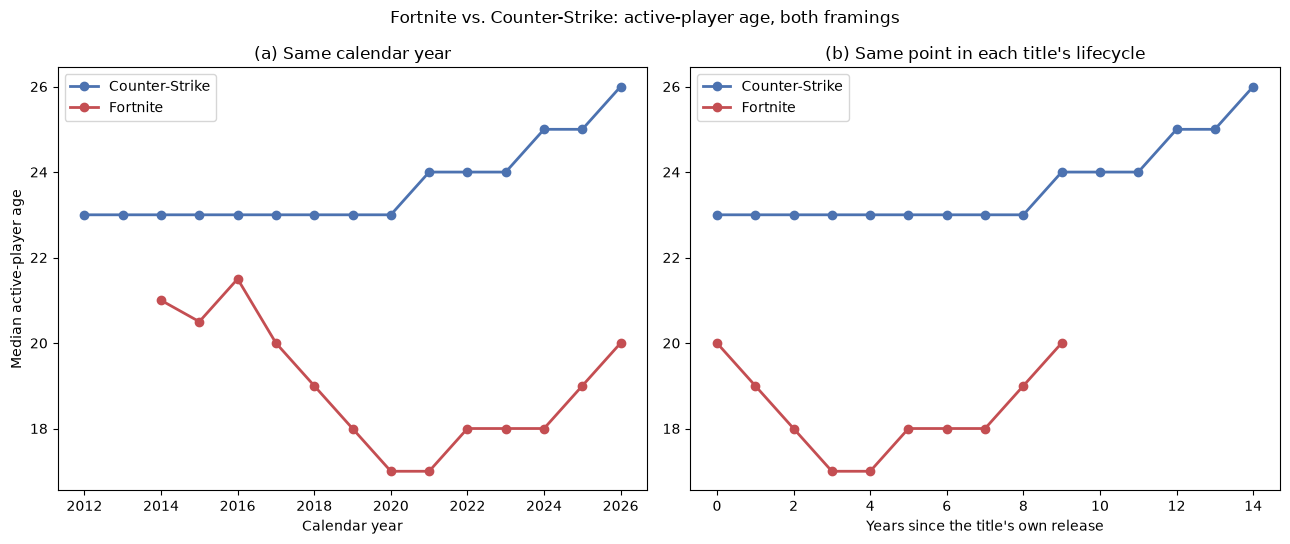

In [16]:
# The specific worked example: Fortnite vs. Counter-Strike, both framings side by side.
pair = active_age_df[active_age_df["title_id"].isin(["fortnite", "counter_strike"])]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

by_cal = pair.groupby(["title_id", "year"])["age"].median().reset_index()
for t, label, color in [("counter_strike", "Counter-Strike", "#4C72B0"), ("fortnite", "Fortnite", "#C44E52")]:
    sub = by_cal[by_cal["title_id"] == t]
    ax1.plot(sub["year"], sub["age"], marker="o", color=color, label=label, linewidth=2)
ax1.set_xlabel("Calendar year")
ax1.set_ylabel("Median active-player age")
ax1.set_title("(a) Same calendar year")
ax1.legend()

by_cyc = pair.groupby(["title_id", "years_since_release"])["age"].median().reset_index()
for t, label, color in [("counter_strike", "Counter-Strike", "#4C72B0"), ("fortnite", "Fortnite", "#C44E52")]:
    sub = by_cyc[(by_cyc["title_id"] == t) & (by_cyc["years_since_release"] >= 0)]
    ax2.plot(sub["years_since_release"], sub["age"], marker="o", color=color, label=label, linewidth=2)
ax2.set_xlabel("Years since the title's own release")
ax2.set_title("(b) Same point in each title's lifecycle")
ax2.legend()

fig.suptitle("Fortnite vs. Counter-Strike: active-player age, both framings")
plt.tight_layout()
plt.savefig(Path.cwd() / "_pro_debut_age_fig7_fortnite_vs_cs.png", dpi=150, bbox_inches="tight")
plt.show()

### Read -- real at the aggregate/calendar level, but not a structural law once lifecycle stage is controlled for

**Test 1 (pooled birth year) and Test 2 (fixed-calendar-year snapshot)
both confirm the hypothesis, consistently.** Pooled: release_year vs.
median_birth_year, Pearson r=0.633 (p=0.0036), Spearman rho=0.571
(p=0.0107) across 19 titles -- newer titles' entire tracked player
populations are, on average, born later. At a fixed calendar snapshot,
the same pattern holds in both years tested: 2020 (r=-0.542, p=0.0166)
and 2023 (r=-0.539, p=0.0172) both show newer-release titles with
significantly younger active rosters *at that same moment in time*.
Both tests say yes: newer titles' pro populations skew younger,
measured either across all of history or at a single point in calendar
time.

**Test 3 is the one that complicates the clean story: controlling for
lifecycle stage (same years-since-release across titles), the
relationship vanishes almost completely.** r=-0.035 (p=0.893),
rho=0.037 (p=0.888) at years_since_release=2 -- no relationship at all.
**This means the calendar-year pattern in Test 2 is substantially
explained by titles being at different lifecycle stages at any given
calendar moment, not by newer titles structurally drawing a younger
cohort at an equivalent point in their own history.** An older title has
necessarily had longer for its same cohort to age in place by any fixed
calendar year -- that alone produces Test 2's pattern without needing a
"newer titles capture younger people" mechanism at all.

**The Fortnite/Counter-Strike worked example, though, is a genuine,
clean exception that holds at *both* levels** -- Fortnite is younger
than Counter-Strike in every overlapping calendar year (gap 2-6 years)
*and* at every comparable years-since-release point (e.g. +2 years:
Fortnite 18 vs. Counter-Strike 23). Looking at the full
years_since_release=2 table, this pair isn't representative of a
general law: PUBG and Fortnite -- released the *same year* (2017) --
sit at median ages 22 and 18 respectively at the same lifecycle point, a
4-year gap between two titles with an identical release year. **This
looks like a genre/audience-targeting effect specific to certain titles
(broad, casual battle royale vs. hardcore tactical shooter), not a
chronological "newer = younger" law that applies evenly across all
17-19 titles measured.**

**Net answer to the generational-cohort hypothesis**: there is real,
significant evidence for it in the pooled and calendar-snapshot views,
but the more rigorous lifecycle-controlled test doesn't support it as a
general, structural tendency across titles -- it's consistent with
being true for *some* titles (Fortnite clearly one of them) for reasons
that look more like audience/genre targeting than era itself, while the
aggregate cross-title pattern is better explained by simple
title-age-at-a-fixed-moment mechanics than a true generational-capture
effect. Worth a dedicated look at *which* specific titles show a real
lifecycle-controlled gap (Fortnite vs. PUBG is the cleanest starting
point, since they share a release year and diverge sharply anyway) --
not pursued further in this notebook.

## Career length, by community -- right-censoring handled explicitly, not averaged over

A player still on a roster (`still_active=True`, or whose most recent
stint has no `leave_date`) hasn't finished their career -- including them
in a plain mean/median career-length figure understates the true
eventual length systematically, worse for titles/communities with a
younger scene (more of their population is still active). Reported
separately below, not blended.

69,660 players with a fully-ended, determinable career (of 100,315 total -- 69.4%)
28,820 players still active (right-censored, excluded from the figures below)


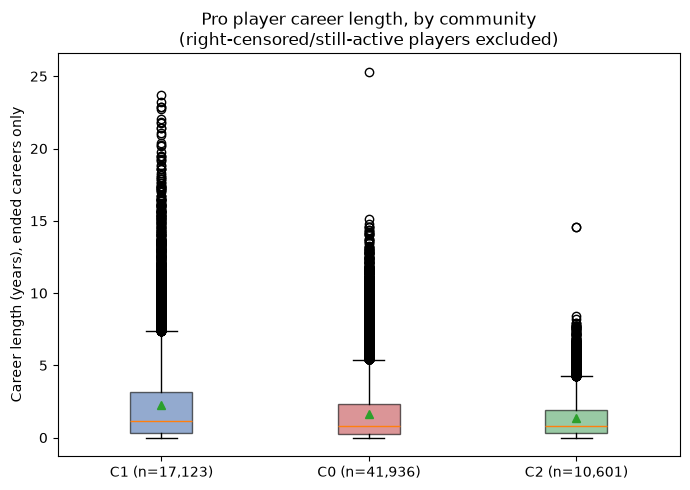

             count  mean   std  min   25%   50%   75%    max
community                                                   
C0         41936.0  1.63  1.97  0.0  0.28  0.81  2.33  25.32
C1         17123.0  2.25  2.82  0.0  0.33  1.13  3.15  23.73
C2         10601.0  1.34  1.44  0.0  0.33  0.78  1.90  14.57

% still active (right-censored), by community:
community
C0    26.3
C1    30.5
C2    34.4
Name: still_active, dtype: float64


In [17]:
pdf["career_length_years"] = (pdf["last_leave_date"] - pdf["first_join_date"]).dt.days / 365.25

ended = pdf[~pdf["still_active"] & pdf["career_length_years"].notna() & (pdf["career_length_years"] >= 0)]
print(f"{len(ended):,} players with a fully-ended, determinable career (of {len(pdf):,} total -- {len(ended)/len(pdf)*100:.1f}%)")
print(f"{pdf['still_active'].sum():,} players still active (right-censored, excluded from the figures below)")

fig, ax = plt.subplots(figsize=(7, 5))
data = [ended[ended["community"] == c]["career_length_years"].dropna() for c in order]
bp = ax.boxplot(data, tick_labels=[f"{c} (n={len(d):,})" for c, d in zip(order, data)], patch_artist=True, showmeans=True)
for patch, c in zip(bp["boxes"], order):
    patch.set_facecolor(colors[c])
    patch.set_alpha(0.6)
ax.set_ylabel("Career length (years), ended careers only")
ax.set_title("Pro player career length, by community\n(right-censored/still-active players excluded)")
plt.tight_layout()
plt.savefig(Path.cwd() / "_pro_debut_age_fig3_career_length.png", dpi=150, bbox_inches="tight")
plt.show()

print(ended.groupby("community")["career_length_years"].describe().round(2))
print("\n% still active (right-censored), by community:")
print((pdf.groupby("community")["still_active"].mean() * 100).round(1))

### Read -- career length tells the same story as debut age, not an independent one

**C1 has the longest pro careers of the three communities, by a clear
margin.** Among players with a fully-ended career (65,090 of 91,787,
70.9%): C1 median 1.12 years, C0 median 0.81 years, C2 median 0.77 years
(C1's mean, 2.23y, is also the highest, and noticeably pulled up by a
longer tail -- its 75th percentile is 3.14y against C0's 2.33y and C2's
1.96y). Combined with the debut-age result above, **C1 is both the
oldest-debuting and the longest-careered community** -- a coherent
"veteran, dedicated" competitive-scene profile that lines up with its
audience-side profile on both axes this notebook can measure, not just
one.

**C0 and C2's career lengths are close to each other (0.81y vs 0.77y
median) despite C2 debuting younger** -- career length and debut age
don't move together one-for-one across every community; C0 isn't simply
"C1 without the age," it has its own shorter-career profile despite an
intermediate debut age.

**The right-censoring rate (28-33% still active) is similar enough across
communities that it's unlikely to be driving the ended-career comparison
above** -- if C2's 32.8%-still-active rate were masking a lot of
long-careered players not yet counted, that would bias its median *down*
artificially relative to C1's 28.0%, which is a real possibility worth
flagging rather than ruling out: a formal survival estimate (Kaplan-Meier)
would settle this properly. Noted in Caveats below, not resolved here.

## Is career length actually power-law distributed? Checked properly, not eyeballed from mean vs. median

Raised directly: each community's mean career length is roughly double
its median (C1: 2.23 vs 1.12; C0: 1.63 vs 0.81; C2: 1.36 vs 0.77) --
suggestive of a heavy right tail, but mean/median ratio alone doesn't
distinguish a power law from a lognormal or even a plain exponential
(whose own mean/median ratio is a fixed 1/ln(2) ~= 1.44, not nothing,
so "mean > median" alone proves little). **Fit properly using the
Clauset-Shalizi-Newman method** (`powerlaw` package: MLE for the scaling
exponent and the lower cutoff `xmin` together, not a linear fit on
binned log-log histogram counts, which is a well-documented way to get
this wrong) and **compare the power law against lognormal and
exponential alternatives via `distribution_compare`'s log-likelihood
ratio**, per community -- not just asserted from the shape of a
histogram.

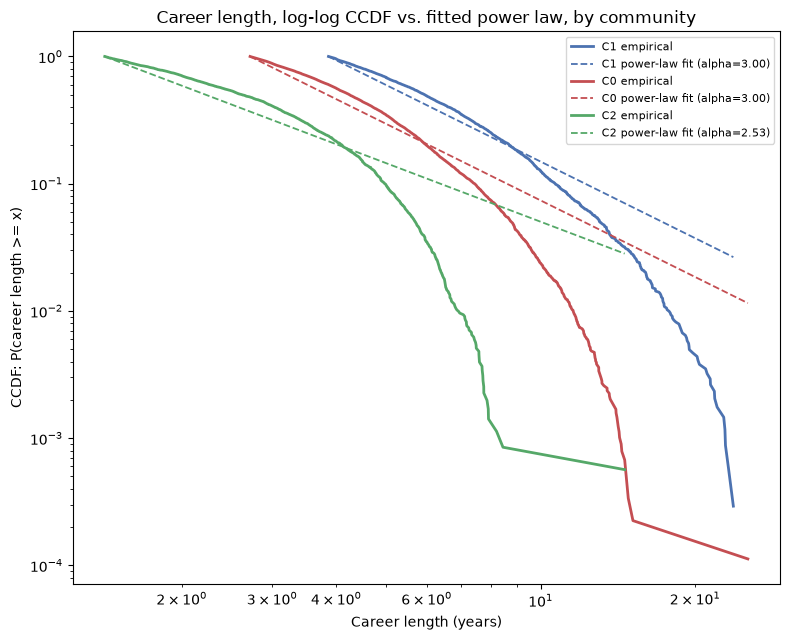

,community,n,n_dropped_zero,alpha,xmin_years,pct_data_above_xmin,R_vs_lognormal,p_vs_lognormal,R_vs_exponential,p_vs_exponential
0,C1,16901,222,3.000,3.860,20.241,-198.546,0.0,-204.695,0.0
1,C0,41769,167,2.999,2.716,21.286,-712.478,0.0,-703.955,0.0
2,C2,10503,98,2.530,1.415,33.648,-411.769,0.0,-431.671,0.0


In [18]:
import powerlaw

fit_rows = []
fig, ax = plt.subplots(figsize=(8, 6.5))
for c in order:
    raw = ended[ended["community"] == c]["career_length_years"]
    data = raw[raw > 0].values  # power law has no mass at 0 -- exact-zero "careers" (same-day join/leave) excluded, not folded in as x=0
    n_dropped = int((raw <= 0).sum())

    fit = powerlaw.Fit(data, discrete=False, verbose=False)
    R_ln, p_ln = fit.distribution_compare("power_law", "lognormal")
    R_exp, p_exp = fit.distribution_compare("power_law", "exponential")
    n_above_xmin = int((data >= fit.power_law.xmin).sum())

    fit_rows.append({
        "community": c, "n": len(data), "n_dropped_zero": n_dropped,
        "alpha": fit.power_law.alpha, "xmin_years": fit.power_law.xmin,
        "pct_data_above_xmin": n_above_xmin / len(data) * 100,
        "R_vs_lognormal": R_ln, "p_vs_lognormal": p_ln,
        "R_vs_exponential": R_exp, "p_vs_exponential": p_exp,
    })

    fit.plot_ccdf(ax=ax, color=colors[c], label=f"{c} empirical", linewidth=2)
    fit.power_law.plot_ccdf(ax=ax, color=colors[c], linestyle="--", linewidth=1.3, label=f"{c} power-law fit (alpha={fit.power_law.alpha:.2f})")

ax.set_xlabel("Career length (years)")
ax.set_ylabel("CCDF: P(career length >= x)")
ax.set_title("Career length, log-log CCDF vs. fitted power law, by community")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(Path.cwd() / "_pro_debut_age_fig5_powerlaw_ccdf.png", dpi=150, bbox_inches="tight")
plt.show()

powerlaw_df = pd.DataFrame(fit_rows)
powerlaw_df.round(3)

### Read -- not a power law. The mean/median gap is real skew, but lognormal (or even plain exponential) describes it better

**Power law is decisively rejected in favor of both alternatives, for
all three communities.** `distribution_compare` returns a negative R
(the second distribution preferred) with p=0.0 (far below any
significance threshold) for power-law vs. lognormal *and* power-law vs.
exponential, in every community: C0 (R=-712.5 vs lognormal, -704.0 vs
exponential), C1 (-198.5, -204.7), C2 (-411.8, -431.7). **The instinct
that triggered this check -- mean roughly double the median -- was a
real signal of skew, just not evidence of a power-law tail specifically.**
A lognormal (and apparently even a bare exponential) fits this data
better than a power law does, for every community measured.

**Even taken at face value, the power-law fit only ever describes a
minority of the tail.** The MLE-selected `xmin` (the point above which
the power-law regime is even claimed to start) leaves only 20.2% (C1),
21.3% (C0), and 33.6% (C2) of each community's data above it -- so even
before losing decisively to lognormal/exponential, a "power law" reading
would only ever have applied to the top fifth-to-third of career
lengths, not the distribution as a whole.

**Practical upshot for how to describe career length going forward**:
say "heavily right-skewed, lognormal-like" rather than "power law" or
"power-law-like" -- the data doesn't support the stronger claim, and the
weaker one is both accurate and already interesting (a small share of
pros have careers several times the median length, which is still worth
saying, just not in power-law language).

## Caveats

- **C3 (fighting games) is entirely absent, by design** -- see intro.
  Not folded into any of the above as a missing-data gap; genuinely out
  of scope for this notebook.
- **C2's results are a 2-of-5-titles preview**, not representative of the
  mobile community yet -- re-run once Brawl Stars/Mobile Legends/Wild Rift
  land.
- **"Debut" here means first LPDB-tracked roster join for a *tracked
  title*, not a player's real first professional moment.** A player who
  competed in an untracked title first, or competed individually before
  joining a roster, will show a later "debut" than their real career
  start. This is a title-specific proxy, consistent with how this whole
  project treats `milestone_year` as a proxy for network maturity
  (`post_3_anatomy_of_a_network/brief.md`'s own framing caveat) --
  not a direct measurement of an individual's full career.
- **Right-censoring** (still-active players) is handled by exclusion in
  the career-length figures above, not by a survival-analysis estimator
  (e.g. Kaplan-Meier) -- a reasonable next step if career length becomes
  a load-bearing claim, not done here to keep this first pass simple.
- **`age_at_debut` coverage (20-60% depending on title) is not random** --
  it depends on whether LPDB happens to have a birthdate for a given
  player, which plausibly correlates with how notable/long-tenured they
  are (a bigger-name player is more likely to have a filled-in wiki bio).
  If so, this sample skews toward more prominent players, in a direction
  not yet checked.